In [1]:
import numpy as np                                                                                                                                                          
import matplotlib.pyplot as plt                                                                                                                                             
import sys                                                                                                                                                                  
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work')                                                                                                           
                                                                                                                                                                            
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                  
import cupy as cp 

try:                                                                                                                                                                        
    import cupy as cp                                                                                                                                                       
    xp = cp                                                                                                                                                                 
    use_gpu = True                                                                                                                                                          
except ImportError:                                                                                                                                                         
    xp = np     
    
    use_gpu = False      

force_backend = "cuda12x"
                                                                                                                                               


In [2]:
                                                                                                                                       
T = 3/12        # years                 
dt = 10.0       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=1)                                                                                                    
         

In [4]:
%%time
# generate signal       
wave_params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,                                                                                                            
                Phi_phi0, Phi_theta0, Phi_r0]                                                                                  
# emri_kwargs = {"T": T, "dt": dt}                                                                                                                              
                                                                                                                                                                            
signal = xp.array(waveform_response(*wave_params, T=T, dt=dt))
print("signal shape:", signal.shape)                                                                                                                                        
                           

signal shape: (3, 788953)
CPU times: user 71.4 ms, sys: 3.95 ms, total: 75.4 ms
Wall time: 81.2 ms


In [5]:
# build gwf class                                                                                                                                                     
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)


In [6]:
# check inner prod and snr of signal 

signal_f = gwf.freq_wave(signal)                                                                                                                                            
inner_signal = xp.asarray(gwf.inner(signal_f, signal_f))
print('inner: ', inner_signal.get())
snr = xp.sqrt(inner_signal)
print('snr: ', snr.get())


inner:  754.2360381085074
snr:  27.463358099629904


In [7]:
n_realizations = 1000                                                                                                                                                       
inner_products = [] 
noise_realizations = []                                                                                                                                                                                                                                                                                                                                                  
for i in range(n_realizations):                                                                                                                                             
    noise_td = gwf.generate_colored_noise(seed=i) 
    noise_realizations.append(noise_td)                                                                                                                                                                                                                                                                                                       
    noise_f = gwf.freq_wave(noise_td)                                                                                                                                       
    ip = xp.asarray(gwf.inner(noise_f, signal_f))
    inner_products.append(ip)

In [8]:
ip_arr = xp.array(inner_products)
mean_ip = xp.mean(ip_arr)
print('Expectation val: ', mean_ip.get())
#NOTE: should be ~0

Expectation val:  1.2833458404577207


In [9]:
var_ip = xp.var(ip_arr)
print('Var: ', var_ip.get())

Var:  744.7022349519832


In [10]:
ratio = var_ip/inner_signal
print('Ratio:', ratio.get())

Ratio: 0.9873596557644828


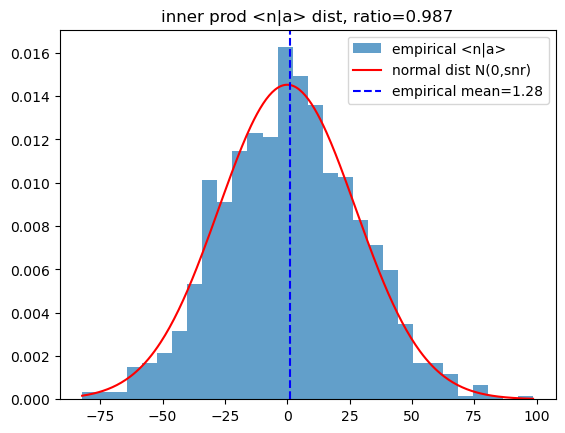

In [11]:
                                                                                                                                                                     
# mean plot                 
# # the expected std is the snr
snr_np = snr.get()                                                                                                                                          
x = np.linspace(ip_arr.get().min(), ip_arr.get().max(), 300)
gaussian = np.exp(-0.5*(x/snr_np)**2)/(snr_np*np.sqrt(2*np.pi))

plt.hist(ip_arr.get(), bins=30, density=True, alpha=0.7, label="empirical <n|a>")
plt.plot(x, gaussian, 'r-', label=f"normal dist N(0,snr)")                                                                      
plt.axvline(mean_ip.get(), color='blue', linestyle='--', label=f"empirical mean={mean_ip.get():.3g}")
plt.title(f"inner prod <n|a> dist, ratio={ratio.get():.3g}")                                                                                                                 
plt.legend()  
plt.show()                      
                                                                                                                                                                         

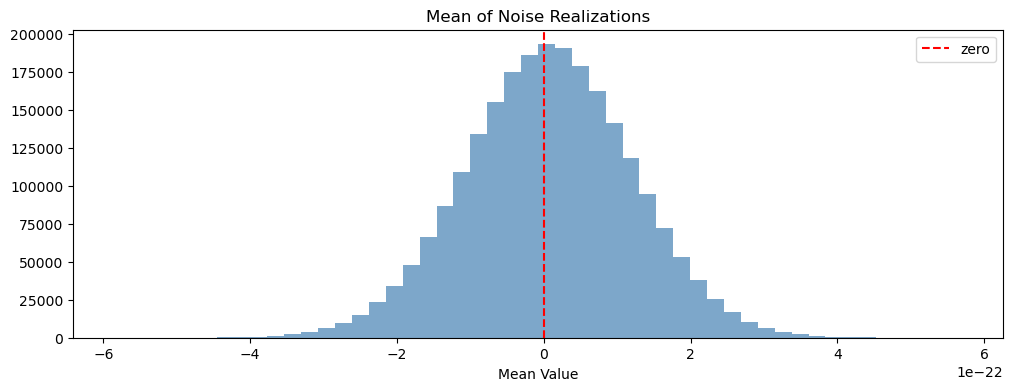

In [12]:
fig, axes = plt.subplots(figsize=(12, 4))
noise_realizations = xp.stack(noise_realizations)
mean_noise = noise_realizations.mean(axis=0).get()
plt.hist(mean_noise.flatten(), bins=50, alpha=0.7, color="steelblue")                                                                                                                                                
plt.axvline(0, color="red", linestyle="--", label="zero")                                                                                                                                                            
plt.title("Mean of Noise Realizations")
plt.xlabel("Mean Value")
plt.legend()
plt.show()                                                                                                                                                          


In [13]:
print(mean_noise)

[[ 9.41001870e-23  1.53412363e-22 -1.89756917e-22 ...  7.37567930e-27
   6.37687039e-23 -1.13967968e-22]
 [-1.86994761e-22  1.14678976e-22  3.10175741e-23 ...  3.61156049e-26
   5.84118052e-23 -8.76739201e-24]
 [ 8.05113990e-23 -3.85223808e-23 -1.25776555e-23 ... -7.06108430e-24
  -2.97454843e-23 -2.97628284e-23]]


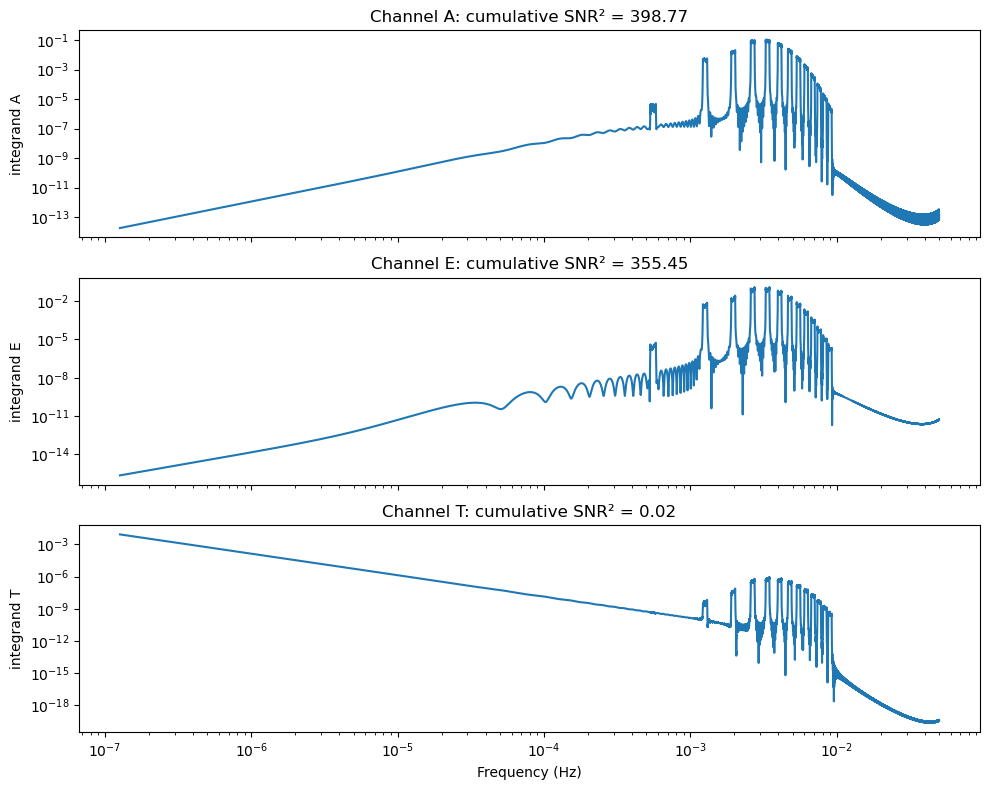

In [14]:
                                                                                                                                                                                         
df = 1 / (gwf.N * gwf.dt)                                                                                                                                                                                           
freqs = np.fft.rfftfreq(gwf.N, gwf.dt)[1:]  # drop DC
                                                                                                                                                                                                                                                                                                                                                                       
sens=gwf.PSD.get()                                                                                                                                                                        
                                                                                                                                                                                                                    
channel_names = ['A', 'E', 'T']         
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)                                                                                                                                                        
                                                                                                                                                                                                                    
for i, ax in enumerate(axes):
    Hf = signal_f.get()[i, 1:]          # drop DC, shape (N//2,)                                                                                                                                                       
    integrand = 4 * df * np.abs(Hf)**2 / sens[i]                                                                                                                                                                  
    ax.loglog(freqs, integrand)
    ax.set_ylabel(f'integrand {channel_names[i]}')                                                                                                                                                                  
    ax.set_title(f'Channel {channel_names[i]}: cumulative SNR² = {np.cumsum(integrand)[-1]:.2f}')                                                                                                                   
                                                                                                                                                                                                                    
axes[-1].set_xlabel('Frequency (Hz)')                                                                                                                                                                               
plt.tight_layout()                                                                                                                                                                                                  
plt.show()                                                                                                                                                                                                          
                                        
